#**UTS soal 1**
#**Prepocessing dan Klasifikasi**

##**Prepocessing**

**Import Library**

In [14]:
# 1. Import library
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import joblib
import re


In [15]:
pip install Sastrawi


**Input Data**

In [16]:
#Menampilkan Data
import pandas as pd

# Baca file yang sudah diunggah
df = pd.read_csv("Berita.csv")

# Lihat nama-nama kolom dan contoh data
print("Nama-nama kolom:")
print(df.columns)

print("\nContoh 100 baris pertama:")
print(df.head())

Nama-nama kolom:
Index(['No', 'judul', 'berita', 'tanggal', 'kategori', 'link'], dtype='object')

Contoh 100 baris pertama:
   No                                              judul  \
0   1  Airlangga Harap Kenaikan UMP Tingkatkan Daya B...   
1   2  PT SIER Beri Penghargaan untuk 50 Tenant Terba...   
2   3  Prabowo Bakal Bentuk Kementerian Penerimaan Ne...   
3   4  Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...   
4   5  Pemerintah Segera Bentuk Satgas PHK Usai Tetap...   

                                              berita  \
0  Menteri Koordinator (Menko) Bidang Perekonomia...   
1  Dalam rangka memeriahkan hari jadi ke-50, PT S...   
2  Wacana Presiden Prabowo Subianto akan membentu...   
3  BPJS Ketenagakerjaan dan Kementerian Agama (Ke...   
4  Pemerintah akan segera membentuk Satuan Tugas ...   

                         tanggal kategori  \
0  Minggu, 01 Des 2024 23:40 WIB  Ekonomi   
1  Minggu, 01 Des 2024 20:45 WIB  Ekonomi   
2  Minggu, 01 Des 2024 19:40 WIB  Ekonomi  

In [17]:
print(df.columns)


Index(['No', 'judul', 'berita', 'tanggal', 'kategori', 'link'], dtype='object')


In [18]:
# Tampilkan semua kategori unik
print(df['kategori'].unique())

# Hitung jumlah kategori unik
print("Jumlah kategori:", df['kategori'].nunique())


['Ekonomi' 'Olahraga' 'Nasional' 'Internasional']
Jumlah kategori: 4


**Prepocessing**

In [19]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# Unduh stopwords jika belum
nltk.download('stopwords')

# Load data
df = pd.read_csv("Berita.csv")
kolom_teks = 'berita'

# Kamus normalisasi
normalisasi_kata = {
    'tdk': 'tidak', 'gk': 'tidak', 'yg': 'yang', 'dr': 'dari',
    'dgn': 'dengan', 'utk': 'untuk', 'sdh': 'sudah',
    'blm': 'belum', 'sbg': 'sebagai',
}

# Stopwords bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
df['case_folding'] = df[kolom_teks].fillna('').astype(str).str.lower()


In [21]:
def cleaning(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # hanya huruf dan spasi
    text = re.sub(r'\s+', ' ', text).strip()  # hapus spasi ganda
    return text

df['cleaning'] = df['case_folding'].apply(cleaning)


In [24]:
# Kamus kata tidak baku → baku
normalisasi_kata = {
    'tdk': 'tidak', 'gk': 'tidak', 'yg': 'yang', 'dr': 'dari',
    'dgn': 'dengan', 'utk': 'untuk', 'sdh': 'sudah',
    'blm': 'belum', 'sbg': 'sebagai', 'aja': 'saja',
    'klo': 'kalau', 'bgt': 'banget', 'kmrn': 'kemarin',
    'bsk': 'besok', 'sm': 'sama'
}

def normalisasi(tokens):
    return [normalisasi_kata.get(token, token) for token in tokens]

df['normalisasi'] = df['tokenizing'].apply(normalisasi)


In [25]:
df['stemming'] = df['normalisasi'].apply(lambda tokens: [stemmer.stem(kata) for kata in tokens])

In [26]:
df['remove_stopwords'] = df['stemming'].apply(lambda tokens: [kata for kata in tokens if kata not in stop_words])

In [27]:
df['hasil_akhir'] = df['remove_stopwords'].apply(lambda tokens: ' '.join(tokens))

In [28]:
# Simpan hasil preprocessing ke file Excel
df.to_csv("hasil_preprocessing_berita.csv", index=False)


In [30]:
# Tampilkan hasil per langkah untuk 5 baris pertama
print("===== Data Asli (Kolom 'berita') =====")
print(df['berita'].head(), end='\n\n')

print("===== Setelah Case Folding =====")
print(df['case_folding'].head(), end='\n\n')

print("===== Setelah Cleaning =====")
print(df['cleaning'].head(), end='\n\n')

print("===== Setelah Tokenizing =====")
print(df['tokenizing'].head(), end='\n\n')

print("===== Setelah Normalisasi Kata Tidak Baku =====")
print(df['normalisasi'].head(), end='\n\n')

print("===== Setelah Stemming =====")
print(df['stemming'].head(), end='\n\n')

print("===== Setelah Stopword Removal =====")
print(df['remove_stopwords'].head(), end='\n\n')

print("===== Teks Akhir Setelah Semua Proses =====")
print(df['hasil_akhir'].head(), end='\n\n')


===== Data Asli (Kolom 'berita') =====
0    Menteri Koordinator (Menko) Bidang Perekonomia...
1    Dalam rangka memeriahkan hari jadi ke-50, PT S...
2    Wacana Presiden Prabowo Subianto akan membentu...
3    BPJS Ketenagakerjaan dan Kementerian Agama (Ke...
4    Pemerintah akan segera membentuk Satuan Tugas ...
Name: berita, dtype: object

===== Setelah Case Folding =====
0    menteri koordinator (menko) bidang perekonomia...
1    dalam rangka memeriahkan hari jadi ke-50, pt s...
2    wacana presiden prabowo subianto akan membentu...
3    bpjs ketenagakerjaan dan kementerian agama (ke...
4    pemerintah akan segera membentuk satuan tugas ...
Name: case_folding, dtype: object

===== Setelah Cleaning =====
0    menteri koordinator menko bidang perekonomian ...
1    dalam rangka memeriahkan hari jadi ke pt surab...
2    wacana presiden prabowo subianto akan membentu...
3    bpjs ketenagakerjaan dan kementerian agama kem...
4    pemerintah akan segera membentuk satuan tugas ...
Name: clea

In [12]:
print(df.columns)


Index(['No', 'judul', 'berita', 'tanggal', 'kategori', 'link'], dtype='object')


In [13]:
df['tokens'] = df['berita'].apply(lambda x: x.split())


**Ekstraksi Fitur**

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Hapus baris dengan teks kosong
df = df[df['berita'].notna()]

# Inisialisasi vectorizer
vectorizer = TfidfVectorizer()

# Transformasi TF-IDF
tfidf_matrix = vectorizer.fit_transform(df['berita'])

# Ubah ke DataFrame
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Tambahkan kolom label agar siap klasifikasi
df_tfidf['kategori'] = df['kategori'].values

# Tampilkan hasil
print("===== Ekstraksi Fitur TF-IDF (5 data pertama) =====")
print(df_tfidf.head())

===== Ekstraksi Fitur TF-IDF (5 data pertama) =====
    00  000  001  002  0027  003  0040990  005  008   01  ...  zwolle   ½a  \
0  0.0  0.0  0.0  0.0   0.0  0.0      0.0  0.0  0.0  0.0  ...     0.0  0.0   
1  0.0  0.0  0.0  0.0   0.0  0.0      0.0  0.0  0.0  0.0  ...     0.0  0.0   
2  0.0  0.0  0.0  0.0   0.0  0.0      0.0  0.0  0.0  0.0  ...     0.0  0.0   
3  0.0  0.0  0.0  0.0   0.0  0.0      0.0  0.0  0.0  0.0  ...     0.0  0.0   
4  0.0  0.0  0.0  0.0   0.0  0.0      0.0  0.0  0.0  0.0  ...     0.0  0.0   

   ½cuta   ½e  ½es   ½n   ½s  ½squez   ½ï  ãžle  
0    0.0  0.0  0.0  0.0  0.0     0.0  0.0   0.0  
1    0.0  0.0  0.0  0.0  0.0     0.0  0.0   0.0  
2    0.0  0.0  0.0  0.0  0.0     0.0  0.0   0.0  
3    0.0  0.0  0.0  0.0  0.0     0.0  0.0   0.0  
4    0.0  0.0  0.0  0.0  0.0     0.0  0.0   0.0  

[5 rows x 26286 columns]


**LDA**

In [17]:
pip install gensim

In [19]:
from gensim import corpora, models

dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

lda_model = models.LdaModel(corpus, num_topics=10, id2word=dictionary, passes=10, random_state=42)
for idx, topic in lda_model.print_topics(num_topics=5):
    print(f"Topik {idx}: {topic}")

# === 4. Tampilkan topik yang ditemukan ===
for idx, topic in lda_model.print_topics(num_topics=5):
    print(f"Topik {idx}: {topic}\n")

# === 5. Ubah distribusi topik tiap dokumen jadi fitur numerik ===
lda_features = [lda_model.get_document_topics(doc, minimum_probability=0) for doc in corpus]

# Konversi ke array numpy
X = np.array([[prob for _, prob in doc] for doc in lda_features])
print("Bentuk fitur LDA:", X.shape)


Topik 2: 0.014*"yang" + 0.012*"di" + 0.011*"dan" + 0.008*"KPK" + 0.007*"kasus" + 0.006*"untuk" + 0.006*"pada" + 0.005*"Hasto" + 0.005*"dalam" + 0.005*"dari"
Topik 7: 0.022*"yang" + 0.022*"di" + 0.022*"dan" + 0.009*"dari" + 0.009*"untuk" + 0.008*"pada" + 0.008*"Israel" + 0.006*"dalam" + 0.006*"dengan" + 0.006*"akan"
Topik 5: 0.019*"yang" + 0.019*"di" + 0.015*"dan" + 0.007*"itu" + 0.006*"untuk" + 0.006*"dari" + 0.006*"ini" + 0.005*"ke" + 0.005*"dengan" + 0.005*"saya"
Topik 3: 0.015*"dan" + 0.011*"yang" + 0.009*"untuk" + 0.008*"di" + 0.007*"minyak" + 0.005*"dalam" + 0.005*"akan" + 0.005*"dari" + 0.005*"pada" + 0.004*"ini"
Topik 4: 0.018*"di" + 0.013*"yang" + 0.010*"menit" + 0.010*"pada" + 0.009*"dan" + 0.009*"dari" + 0.008*"dengan" + 0.008*"gol" + 0.006*"ke" + 0.006*"Piala"
Topik 4: 0.018*"di" + 0.013*"yang" + 0.010*"menit" + 0.010*"pada" + 0.009*"dan" + 0.009*"dari" + 0.008*"dengan" + 0.008*"gol" + 0.006*"ke" + 0.006*"Piala"

Topik 9: 0.021*"di" + 0.016*"yang" + 0.012*"dan" + 0.012*"Indo

**Split data dan Klasifikasi**

In [20]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (X) dan label (y)
X = df_tfidf.drop(columns='label')
y = df_tfidf['label']

# Split data: 80% latih, 20% uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Cek hasil
print("Jumlah data latih:", X_train.shape[0])
print("Jumlah data uji  :", X_test.shape[0])

Jumlah data latih: 1200
Jumlah data uji  : 300


**Klasifikasi**

In [22]:
y = df["kategori"]

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Contoh teks
X = df['berita']   # kolom teks
y = df['kategori']  # kolom kategori

# Ubah teks ke vektor numerik
vectorizer = TfidfVectorizer()
X_vect = vectorizer.fit_transform(X)

# Bagi train-test
X_train, X_test, y_train, y_test = train_test_split(X_vect, y, test_size=0.2, random_state=42)

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("=== HASIL NAIVE BAYES ===")
print(classification_report(y_test, y_pred_nb))

# SVM
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\n=== HASIL SVM ===")
print(classification_report(y_test, y_pred_svm))


=== HASIL NAIVE BAYES ===
               precision    recall  f1-score   support

      Ekonomi       0.89      0.97      0.93        73
Internasional       0.95      0.98      0.96        84
     Nasional       0.97      0.86      0.91        70
     Olahraga       1.00      0.99      0.99        73

     accuracy                           0.95       300
    macro avg       0.95      0.95      0.95       300
 weighted avg       0.95      0.95      0.95       300


=== HASIL SVM ===
               precision    recall  f1-score   support

      Ekonomi       0.96      0.92      0.94        73
Internasional       0.94      0.96      0.95        84
     Nasional       0.92      0.94      0.93        70
     Olahraga       1.00      0.99      0.99        73

     accuracy                           0.95       300
    macro avg       0.95      0.95      0.95       300
 weighted avg       0.95      0.95      0.95       300



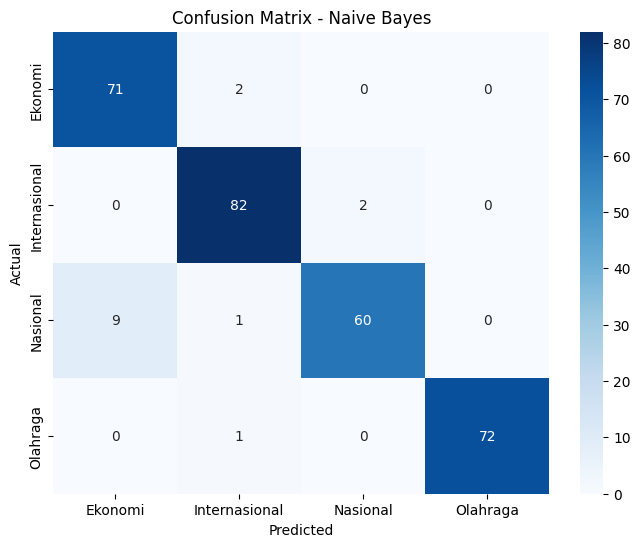

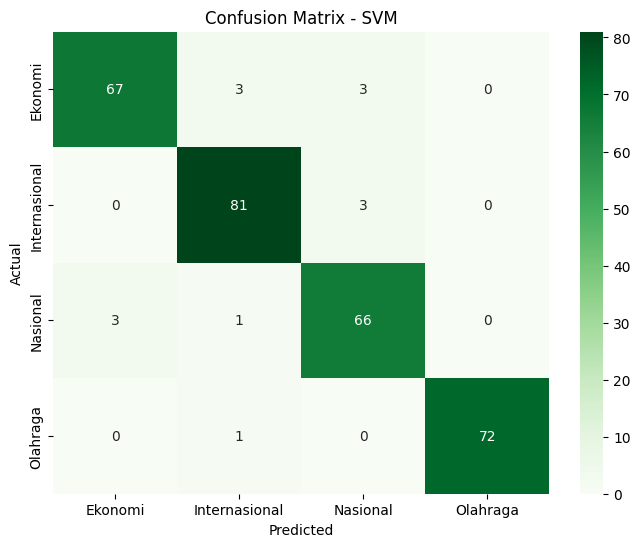

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix Naive Bayes ---
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=nb.classes_, yticklabels=nb.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

# --- Confusion Matrix SVM ---
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()
